I. Imports and Paths

In [2]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
project_root = Path("/Users/lucashuynh/Desktop/Gated-Risk-MCP")   # change this if needed depending on where notebook lives
data_dir = project_root / "Data" / "SROIE"

ocr_dir = data_dir / "0325updated.task1train(626p)"
label_dir = data_dir / "0325updated.task2train(626p)"

print("OCR dir exists:", ocr_dir.exists())
print("Label dir exists:", label_dir.exists())
print("Num OCR files:", len(list(ocr_dir.glob("*.txt"))))
print("Num label files:", len(list(label_dir.glob("*.txt"))))

OCR dir exists: True
Label dir exists: True
Num OCR files: 835
Num label files: 876


II. Match Files by Receipt ID

In [4]:
ocr_ids = {p.stem for p in ocr_dir.glob("*.txt")}
label_ids = {p.stem for p in label_dir.glob("*.txt")}

print("Unique OCR ids:", len(ocr_ids))
print("Unique label ids:", len(label_ids))
print("Overlap:", len(ocr_ids & label_ids))
print("Only in OCR:", len(ocr_ids - label_ids))
print("Only in labels:", len(label_ids - ocr_ids))

Unique OCR ids: 835
Unique label ids: 876
Overlap: 716
Only in OCR: 119
Only in labels: 160


III. Inspect One OCR and One Label File

In [5]:
sample_id = sorted(list(ocr_ids & label_ids))[0]

print("Sample id:", sample_id)

with open(ocr_dir / f"{sample_id}.txt", "r", encoding="utf-8") as f:
    ocr_lines = f.readlines()

print("\nFirst 5 OCR lines:")
for line in ocr_lines[:5]:
    print(line.strip())

with open(label_dir / f"{sample_id}.txt", "r", encoding="utf-8") as f:
    label_data = json.load(f)

print("\nLabel data:")
print(label_data)

Sample id: X00016469612

First 5 OCR lines:
72,25,326,25,326,64,72,64,TAN WOON YANN
50,82,440,82,440,121,50,121,BOOK TA .K(TAMAN DAYA) SDN BND
205,121,285,121,285,139,205,139,789417-W
110,144,383,144,383,163,110,163,NO.53 55,57 & 59, JALAN SAGU 18,
192,169,299,169,299,187,192,187,TAMAN DAYA,

Label data:
{'company': 'BOOK TA .K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'address': 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.', 'total': '9.00'}


IV. Simple OCR Parser

In [6]:
def parse_ocr_file(file_path):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(",")

            # first 8 values are coordinates, rest is text
            coords = parts[:8]
            text = ",".join(parts[8:]).strip()

            if len(coords) != 8:
                continue

            try:
                coords = list(map(int, coords))
            except ValueError:
                continue

            rows.append({
                "x1": coords[0],
                "y1": coords[1],
                "x2": coords[2],
                "y2": coords[3],
                "x3": coords[4],
                "y3": coords[5],
                "x4": coords[6],
                "y4": coords[7],
                "text": text
            })

    return rows

In [7]:
sample_ocr = parse_ocr_file(ocr_dir / f"{sample_id}.txt")

print("Number of OCR rows:", len(sample_ocr))
print("\nFirst 3 parsed rows:")
for row in sample_ocr[:3]:
    print(row)

Number of OCR rows: 44

First 3 parsed rows:
{'x1': 72, 'y1': 25, 'x2': 326, 'y2': 25, 'x3': 326, 'y3': 64, 'x4': 72, 'y4': 64, 'text': 'TAN WOON YANN'}
{'x1': 50, 'y1': 82, 'x2': 440, 'y2': 82, 'x3': 440, 'y3': 121, 'x4': 50, 'y4': 121, 'text': 'BOOK TA .K(TAMAN DAYA) SDN BND'}
{'x1': 205, 'y1': 121, 'x2': 285, 'y2': 121, 'x3': 285, 'y3': 139, 'x4': 205, 'y4': 139, 'text': '789417-W'}


V. Simple Label Parser

In [8]:
def load_label_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return {
        "company": data.get("company", "").strip(),
        "date": data.get("date", "").strip(),
        "address": data.get("address", "").strip(),
        "total": data.get("total", "").strip()
    }

In [9]:
sample_label = load_label_file(label_dir / f"{sample_id}.txt")
sample_label

{'company': 'BOOK TA .K (TAMAN DAYA) SDN BHD',
 'date': '25/12/2018',
 'address': 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.',
 'total': '9.00'}

VI. Match Images

In [10]:
all_jpgs = list(data_dir.rglob("*.jpg"))
all_pngs = list(data_dir.rglob("*.png"))

print("Num jpg files:", len(all_jpgs))
print("Num png files:", len(all_pngs))

print("\nFirst 10 image paths:")
for p in (all_jpgs + all_pngs)[:10]:
    print(p)

Num jpg files: 2154
Num png files: 0

First 10 image paths:
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51005442376.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51009453804.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51006401723.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51006913023.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51007846451.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51006311780.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51005719862.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51007339133.jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X51005605285(2).jpg
/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/032

VII. Image Path Helper Function

In [11]:
def find_image_path(receipt_id, search_root):
    for ext in [".jpg", ".jpeg", ".png"]:
        matches = list(search_root.rglob(f"{receipt_id}{ext}"))
        if matches:
            return matches[0]
    return None

In [12]:
sample_img_path = find_image_path(sample_id, data_dir)
print(sample_img_path)

/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/SROIE/0325updated.task2train(626p)/X00016469612.jpg


VIII. Build One Record Per Receipt

In [13]:
common_ids = sorted(list(ocr_ids & label_ids))

records = []

for receipt_id in common_ids:
    ocr_path = ocr_dir / f"{receipt_id}.txt"
    label_path = label_dir / f"{receipt_id}.txt"
    image_path = find_image_path(receipt_id, data_dir)

    ocr_rows = parse_ocr_file(ocr_path)
    label = load_label_file(label_path)

    full_text = " ".join([row["text"] for row in ocr_rows if row["text"]])

    records.append({
        "receipt_id": receipt_id,
        "ocr_path": str(ocr_path),
        "label_path": str(label_path),
        "image_path": str(image_path) if image_path is not None else None,
        "company": label["company"],
        "date": label["date"],
        "address": label["address"],
        "total": label["total"],
        "num_ocr_lines": len(ocr_rows),
        "ocr_full_text": full_text
    })

df = pd.DataFrame(records)
df.head()

,receipt_id,ocr_path,label_path,image_path,company,date,address,total,num_ocr_lines,ocr_full_text
0,X00016469612,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",9.00,44,TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 7...
1,X00016469619,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,INDAH GIFT & HOME DECO,19/10/2018,"27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...",60.30,48,"TAN WOON YANN INDAH GIFT & HOME DECO 27,JALAN ..."
2,X00016469620,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,MR D.I.Y. (JOHOR) SDN BHD,12-01-19,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",33.90,54,TAN WOON YANN MR D.T.Y. (JOHOR) SDN BHD (CO.RE...
3,X00016469622,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,YONGFATT ENTERPRISE,25/12/2018,NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU,80.90,60,TAN WOON YANN YONGFATT ENTERPRISE (JM0517726) ...
4,X00016469623,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,MR D.I.Y. (M) SDN BHD,18-11-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",30.90,61,TAN WOON YANN MR D.I.Y. (M) SDN BHD (CO. RFG :...


IX. Dataframe Sanity Checks

In [14]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nEmpty string counts:")
for col in ["company", "date", "address", "total", "ocr_full_text"]:
    print(col, (df[col].str.strip() == "").sum())

Shape: (716, 10)

Columns:
['receipt_id', 'ocr_path', 'label_path', 'image_path', 'company', 'date', 'address', 'total', 'num_ocr_lines', 'ocr_full_text']

Missing values:
receipt_id        0
ocr_path          0
label_path        0
image_path       26
company           0
date              0
address           0
total             0
num_ocr_lines     0
ocr_full_text     0
dtype: int64

Empty string counts:
company 0
date 0
address 1
total 1
ocr_full_text 0


In [15]:
df[["receipt_id", "company", "date", "total", "num_ocr_lines"]].sample(5, random_state=42)

,receipt_id,company,date,total,num_ocr_lines
120,X51005663276,SYARIKAT PERNIAGAAN GIN KEE,02/12/2017,7.42,58
331,X51006393376,99 SPEED MART S/B,10-05-17,11.50,29
39,X51005433533,PERNIAGAAN ZHENG HUI,09/03/2018,332.30,107
636,X51008030566,RESTORAN WAN SHENG,09-04-2018,8.60,54
514,X51007225398,ENW HARDWARE CENTRE (M) SDN. BHD.,13/04/2018,27.00,46


In [16]:
row = df.iloc[0]

print("Receipt ID:", row["receipt_id"])
print("Company:", row["company"])
print("Date:", row["date"])
print("Address:", row["address"])
print("Total:", row["total"])
print("Num OCR lines:", row["num_ocr_lines"])
print("\nOCR text preview:")
print(row["ocr_full_text"][:1000])

Receipt ID: X00016469612
Company: BOOK TA .K (TAMAN DAYA) SDN BHD
Date: 25/12/2018
Address: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
Total: 9.00
Num OCR lines: 44

OCR text preview:
TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 789417-W NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR. DOCUMENT NO : TD01167104 DATE: 25/12/2018 8:13:39 PM CASHIER: MANIS MEMBER: CASH BILL CODE/DESC PRICE DISC AMOUNT QTY RM RM 9556939040116 KF MODELLING CLAY KIDDY FISH 1 PC * 9.000 0.00 9.00 TOTAL: ROUR DING ADJUSTMENT: 0.00 ROUND D TOTAL (RM): 9.00 CASH 10.00 CHANGE 1.00 GOODS SOLD ARE NOT RETURNABLE OR EXCHANGEABLE *** *** THANK YOU PLEASE COME AGAIN ! 9.00


X. Image Size Check

In [17]:
widths = []
heights = []

for path in df["image_path"].dropna():
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Num images found:", len(widths))
print("Width range:", min(widths), "to", max(widths))
print("Height range:", min(heights), "to", max(heights))

Num images found: 690
Width range: 436 to 4961
Height range: 605 to 7016


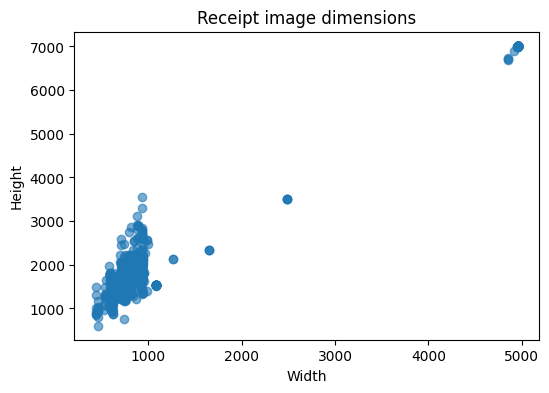

In [18]:
plt.figure(figsize=(6, 4))
plt.scatter(widths, heights, alpha=0.6)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Receipt image dimensions")
plt.show()

XI. Basic Label EDA

OCR Line Count Distribution

In [19]:
df["num_ocr_lines"].describe()

count    716.000000
mean      53.843575
std       17.842845
min       18.000000
25%       42.000000
50%       50.000000
75%       63.000000
max      153.000000
Name: num_ocr_lines, dtype: float64

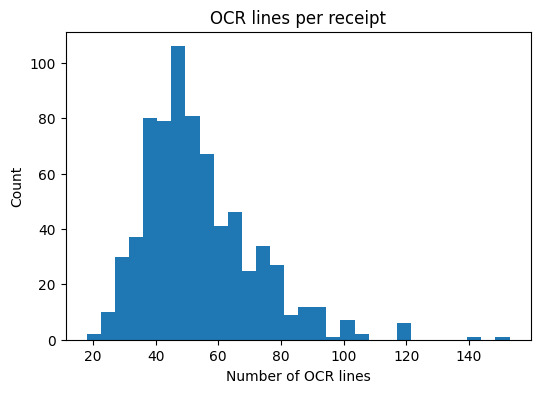

In [20]:
plt.figure(figsize=(6, 4))
plt.hist(df["num_ocr_lines"], bins=30)
plt.xlabel("Number of OCR lines")
plt.ylabel("Count")
plt.title("OCR lines per receipt")
plt.show()

Total Field Distribution

In [21]:
df["total_num"] = pd.to_numeric(df["total"], errors="coerce")

print(df["total_num"].describe())
print("Missing numeric totals:", df["total_num"].isna().sum())

count     625.000000
mean       95.609840
std       546.184192
min        -1.730000
25%         9.900000
50%        28.200000
75%        63.800000
max      7838.800000
Name: total_num, dtype: float64
Missing numeric totals: 91


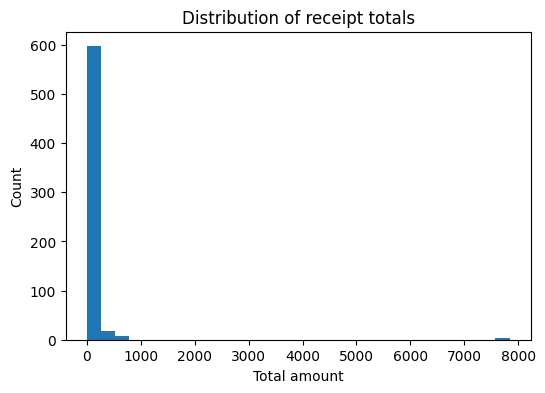

In [22]:
plt.figure(figsize=(6, 4))
plt.hist(df["total_num"].dropna(), bins=30)
plt.xlabel("Total amount")
plt.ylabel("Count")
plt.title("Distribution of receipt totals")
plt.show()

Date Formats

In [24]:
def get_date_format(date_str):
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", date_str):
        return "dd/mm/yyyy"
    if re.fullmatch(r"\d{2}-\d{2}-\d{2}", date_str):
        return "dd-mm-yy"
    if re.fullmatch(r"\d{2}/\d{2}/\d{2}", date_str):
        return "dd/mm/yy"
    return "other"

df["date_format"] = df["date"].apply(get_date_format)
df["date_format"].value_counts()

date_format
dd/mm/yyyy    388
other         161
dd-mm-yy      100
dd/mm/yy       67
Name: count, dtype: int64

Labeled Total Presence

In [25]:
df["total_in_ocr_exact"] = df.apply(
    lambda row: row["total"] in row["ocr_full_text"] if pd.notna(row["ocr_full_text"]) else False,
    axis=1
)

df["total_in_ocr_exact"].value_counts(dropna=False)
print("Match rate:", df["total_in_ocr_exact"].mean())

Match rate: 0.9958100558659218


In [26]:
df.loc[~df["total_in_ocr_exact"], ["receipt_id", "total", "ocr_full_text"]].head(5)

,receipt_id,total,ocr_full_text
253,X51005806678,7838.80,"KAISON FURNISHING SDN BHD L4-17 (B), LEVEL 4, ..."
254,X51005806678(1),7838.80,"KAISON FURNISHING SDN BHD L4-17 (B), LEVEL 4, ..."
255,X51005806678(2),7838.80,"KAISON FURNISHING SDN BHD L4-17 (B), LEVEL 4, ..."


XII. Inspect Potential Data Errors

Duplicate Receipts

In [27]:
base_id_counts = (
    df["receipt_id"]
    .str.replace(r"\(\d+\)$", "", regex=True)
    .value_counts()
)

print("Base IDs with duplicates:")
print(base_id_counts[base_id_counts > 1].head(20))

print("\nNumber of base IDs with duplicates:", (base_id_counts > 1).sum())

Base IDs with duplicates:
receipt_id
X51005587254    3
X51005587267    3
X51005605284    3
X51005605285    3
X51005605286    3
X51005757349    3
X51005757351    3
X51005757353    3
X51005763940    3
X51005806678    3
X51005806679    3
X51007225417    3
X51007225442    3
X51007228448    3
X51007231336    3
X51007231338    3
X51007339166    3
X51007339167    3
X51007339639    3
X51007339642    3
Name: count, dtype: int64

Number of base IDs with duplicates: 69


Totals Failing Numeric Conversion

In [29]:
bad_totals = df.loc[pd.to_numeric(df["total"], errors="coerce").isna(), ["receipt_id", "total"]]
bad_totals.head(20)

,receipt_id,total
35,X51005433492,$8.20
37,X51005433514,$8.20
38,X51005433522,
40,X51005433538,$8.20
41,X51005433541,$8.20
49,X51005442327,$8.60
50,X51005442333,$6.90
56,X51005442376,$7.60
58,X51005442379,$9.20
60,X51005442384,$8.20


In [ ]:
print("Number of bad totals:", len(bad_totals))
print("\nUnique bad total values:")
print(bad_totals["total"].value_counts().head(30))

Number of bad totals: 91

Unique bad total values:
total
$8.20       12
$8.70        6
RM7.70       4
$7.60        2
$7.10        2
RM 34.80     2
RM8.50       2
RM8.20       2
             1
$8.60        1
$6.90        1
$9.20        1
RM 3.90      1
RM4.00       1
RM41.45      1
RM 29.70     1
RM8.60       1
RM39.00      1
RM53.60      1
RM29.30      1
RM367.10     1
RM22.65      1
RM7.00       1
RM3.00       1
RM1.00       1
RM28.05      1
$7.00        1
$9.90        1
RM5.00       1
RM20.40      1
Name: count, dtype: int64


In [30]:
print("Number of bad totals:", len(bad_totals))
print("\nUnique bad total values:")
print(bad_totals["total"].value_counts().head(30))

Number of bad totals: 91

Unique bad total values:
total
$8.20       12
$8.70        6
RM7.70       4
$7.60        2
$7.10        2
RM 34.80     2
RM8.50       2
RM8.20       2
             1
$8.60        1
$6.90        1
$9.20        1
RM 3.90      1
RM4.00       1
RM41.45      1
RM 29.70     1
RM8.60       1
RM39.00      1
RM53.60      1
RM29.30      1
RM367.10     1
RM22.65      1
RM7.00       1
RM3.00       1
RM1.00       1
RM28.05      1
$7.00        1
$9.90        1
RM5.00       1
RM20.40      1
Name: count, dtype: int64


Weird Dates

In [31]:
df.loc[df["date_format"] == "other", ["receipt_id", "date"]].head(30)

,receipt_id,date
7,X00016469676,23-01-2019
10,X51005255805,29-12-2017
35,X51005433492,05 MAR 2018
37,X51005433514,03 MAR 2018
38,X51005433522,10 MAR 2018
40,X51005433538,12 MAR 2018
41,X51005433541,14 MAR 2018
47,X51005441407,5/3/2018
48,X51005441408,10-03-2018
49,X51005442327,18 MAR 2018


In [32]:
print(df.loc[df["date_format"] == "other", "date"].value_counts().head(30))

date
4/02/2017      3
24-MAR-2018    3
11.02.18       3
13 MAY 2018    3
21-03-2018     2
19-03-2018     2
14-03-2018     2
09-04-2018     2
05-JAN-2017    2
30-04-2018     2
30-06-2018     2
06-05-2018     2
23-06-2018     2
11-06-2018     2
04-06-2018     2
26-06-2018     2
20-06-2018     2
23-01-2019     1
29-12-2017     1
05 MAR 2018    1
03 MAR 2018    1
10 MAR 2018    1
12 MAR 2018    1
14 MAR 2018    1
5/3/2018       1
10-03-2018     1
18 MAR 2018    1
27 MAR 2018    1
2018-03-23     1
22 MAR 2018    1
Name: count, dtype: int64


Clean Total into Usable Numeric Column

In [33]:
def clean_total_string(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()
    if x == "":
        return np.nan
    
    x = x.replace(",", "")
    x = x.replace("RM", "")
    x = x.replace("rm", "")
    x = x.strip()
    
    return x

df["total_clean"] = df["total"].apply(clean_total_string)
df["total_num"] = pd.to_numeric(df["total_clean"], errors="coerce")

print(df["total_num"].describe())
print("Missing numeric totals after cleaning:", df["total_num"].isna().sum())

count     681.000000
mean       92.003304
std       524.877933
min        -1.730000
25%         9.500000
50%        28.000000
75%        62.000000
max      7838.800000
Name: total_num, dtype: float64
Missing numeric totals after cleaning: 35


Base Receipt ID Column

In [34]:
df["base_receipt_id"] = df["receipt_id"].str.replace(r"\(\d+\)$", "", regex=True)

In [35]:
print("Unique receipt_id:", df["receipt_id"].nunique())
print("Unique base_receipt_id:", df["base_receipt_id"].nunique())

Unique receipt_id: 716
Unique base_receipt_id: 626


Check if Duplicates Have Same Labels

In [36]:
dup_groups = df.groupby("base_receipt_id").filter(lambda x: len(x) > 1)

dup_summary = (
    dup_groups.groupby("base_receipt_id")
    .agg(
        n_rows=("receipt_id", "size"),
        n_company=("company", "nunique"),
        n_date=("date", "nunique"),
        n_address=("address", "nunique"),
        n_total=("total", "nunique")
    )
    .sort_values("n_rows", ascending=False)
)

dup_summary.head(20)

,n_rows,n_company,n_date,n_address,n_total
base_receipt_id,,,,,
X51005806678,3,1,1,1,1
X51005757349,3,1,1,1,1
X51007339642,3,1,1,1,1
X51007339639,3,1,1,1,1
X51007339167,3,1,1,1,1
X51007339166,3,1,1,1,1
X51007231338,3,1,1,1,1
X51007231336,3,1,1,1,1
X51007228448,3,1,1,1,1


Missing Image Paths

In [37]:
df.loc[df["image_path"].isna(), ["receipt_id", "ocr_path", "label_path"]].head(20)

,receipt_id,ocr_path,label_path
30,X51005361946(1),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
91,X51005568900(1),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
101,X51005587254(1),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
102,X51005587254(2),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
105,X51005587267(2),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
159,X51005705760(1),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
254,X51005806678(1),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
255,X51005806678(2),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
257,X51005806679(1),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...
258,X51005806679(2),/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...,/Users/lucashuynh/Desktop/Gated-Risk-MCP/Data/...


XIII. Create Clean Dataframe

Keep One Row per Base Receipt

In [38]:
df["base_receipt_id"] = df["receipt_id"].str.replace(r"\(\d+\)$", "", regex=True)

df_clean = (
    df.sort_values("receipt_id")
      .drop_duplicates(subset="base_receipt_id", keep="first")
      .copy()
)

print("Raw rows:", len(df))
print("Clean rows:", len(df_clean))
print("Unique base ids:", df['base_receipt_id'].nunique())

Raw rows: 716
Clean rows: 626
Unique base ids: 626


Improve Image Matching for Duplicates

In [39]:
def find_image_path(receipt_id, search_root):
    base_id = re.sub(r"\(\d+\)$", "", receipt_id)

    for ext in [".jpg", ".jpeg", ".png"]:
        exact_matches = list(search_root.rglob(f"{receipt_id}{ext}"))
        if exact_matches:
            return exact_matches[0]

        base_matches = list(search_root.rglob(f"{base_id}{ext}"))
        if base_matches:
            return base_matches[0]

    return None

In [40]:
df["image_path"] = df["receipt_id"].apply(lambda x: find_image_path(x, data_dir))
df_clean["image_path"] = df_clean["receipt_id"].apply(lambda x: find_image_path(x, data_dir))

print("Missing image paths in raw:", df["image_path"].isna().sum())
print("Missing image paths in clean:", df_clean["image_path"].isna().sum())

Missing image paths in raw: 0
Missing image paths in clean: 0


Clean Some Price Totals

In [41]:
def clean_total_string(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    if x == "":
        return np.nan

    x = x.replace(",", "")
    x = x.replace("RM", "")
    x = x.replace("rm", "")
    x = x.replace("$", "")
    x = x.strip()

    return x

df_clean["total_clean"] = df_clean["total"].apply(clean_total_string)
df_clean["total_num"] = pd.to_numeric(df_clean["total_clean"], errors="coerce")

print(df_clean["total_num"].describe())
print("Missing numeric totals in clean df:", df_clean["total_num"].isna().sum())

count     625.000000
mean       69.375008
std       326.279957
min        -1.730000
25%         8.950000
50%        27.000000
75%        60.950000
max      7838.800000
Name: total_num, dtype: float64
Missing numeric totals in clean df: 1


Standardize Date Categories

In [42]:
def get_date_format(date_str):
    if pd.isna(date_str):
        return "missing"

    x = str(date_str).strip()

    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", x):
        return "dd/mm/yyyy"
    if re.fullmatch(r"\d{2}/\d{2}/\d{2}", x):
        return "dd/mm/yy"
    if re.fullmatch(r"\d{2}-\d{2}-\d{2}", x):
        return "dd-mm-yy"
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", x):
        return "dd-mm-yyyy"
    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{4}", x):
        return "d/m/yyyy"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", x):
        return "yyyy-mm-dd"
    if re.fullmatch(r"\d{8}", x):
        return "yyyymmdd"
    if re.fullmatch(r"\d{2} [A-Z]{3} \d{4}", x):
        return "dd MON yyyy"
    if re.fullmatch(r"\d{2} [A-Z]{3} \d{2}", x):
        return "dd MON yy"
    if re.fullmatch(r"\d{2}-[A-Z]{3}-\d{4}", x):
        return "dd-MON-yyyy"
    if re.fullmatch(r"\d{2}-[A-Z]{3}-\d{2}", x):
        return "dd-MON-yy"

    return "other"

df_clean["date_format"] = df_clean["date"].apply(get_date_format)
df_clean["date_format"].value_counts()

date_format
dd/mm/yyyy     330
dd-mm-yy        82
dd-mm-yyyy      70
dd/mm/yy        61
dd MON yyyy     47
other           10
d/m/yyyy         9
dd MON yy        5
dd-MON-yyyy      5
yyyy-mm-dd       4
yyyymmdd         3
Name: count, dtype: int64

XIV. Re-Run Summaries on Clean Data

In [43]:
df_clean["num_ocr_lines"].describe()

count    626.000000
mean      53.715655
std       17.907290
min       18.000000
25%       42.000000
50%       50.000000
75%       63.000000
max      153.000000
Name: num_ocr_lines, dtype: float64

In [44]:
df_clean["total_num"].describe()

count     625.000000
mean       69.375008
std       326.279957
min        -1.730000
25%         8.950000
50%        27.000000
75%        60.950000
max      7838.800000
Name: total_num, dtype: float64

In [45]:
df_clean["date_format"].value_counts()

date_format
dd/mm/yyyy     330
dd-mm-yy        82
dd-mm-yyyy      70
dd/mm/yy        61
dd MON yyyy     47
other           10
d/m/yyyy         9
dd MON yy        5
dd-MON-yyyy      5
yyyy-mm-dd       4
yyyymmdd         3
Name: count, dtype: int64

In [46]:
df_clean["image_path"].isna().sum()

0

Largest Totals

In [47]:
df_clean.nlargest(10, "total_num")[["receipt_id", "company", "date", "total", "total_num", "num_ocr_lines"]]

,receipt_id,company,date,total,total_num,num_ocr_lines
253,X51005806678,KAISON FURNISHING SDN BHD,29-01-18,7838.80,7838.80,53
406,X51006556830,PINGHWAI TRADING SDN BHD,23/09/2017,"1,007.50",1007.50,63
303,X51006335552,YONG SOON FATT S/B,6/2/2017,758.70,758.70,103
310,X51006387847,BEMED (SP) SDN. BHD.,15/APR/2017,635.00,635.00,57
407,X51006556831,PINGHWAI TRADING SDN BHD,30/09/2017,616.60,616.60,63
126,X51005663297,BEYOND BROTHERS HARDWARE,14/03/2018,599.45,599.45,153
55,X51005442361,TIMELESS KITCHENETTE SDN BHD,2018-03-23,593.10,593.10,66
94,X51005568913,IKANO HANDEL SDN BHD,27/07/17,538.00,538.00,38
702,X51008145505,KT WONG TRADING,09/06/2018,489.30,489.30,50
487,X51006913019,AEON CO. (M) BHD,11/05/2018,476.80,476.80,80


Negative or Zero Totals

In [48]:
df_clean.loc[df_clean["total_num"] <= 0, ["receipt_id", "company", "date", "total", "ocr_full_text"]].head(10)

,receipt_id,company,date,total,ocr_full_text
403,X51006556824,GARDENIA BAKERIES (KL) SDN BHD,29/09/2017,-1.73,GARDENIA BAKERIES (KL) SDN BHD (139386 X) LOT ...


Cleaned Totals With and Without Extreme Outliers

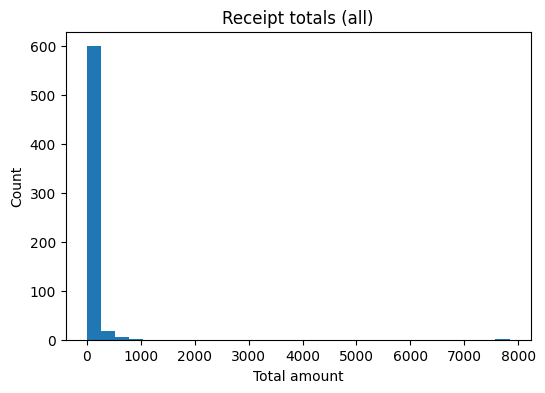

In [49]:
plt.figure(figsize=(6, 4))
plt.hist(df_clean["total_num"].dropna(), bins=30)
plt.xlabel("Total amount")
plt.ylabel("Count")
plt.title("Receipt totals (all)")
plt.show()

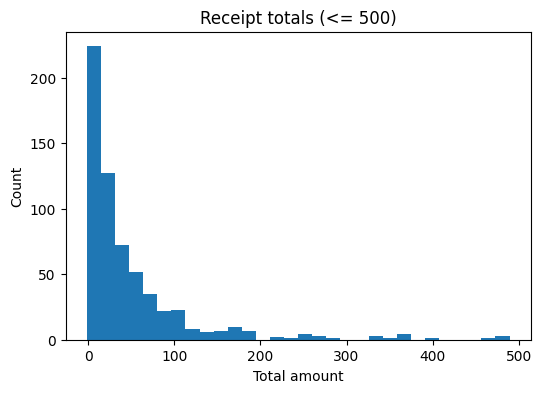

In [50]:
plt.figure(figsize=(6, 4))
plt.hist(df_clean.loc[df_clean["total_num"] <= 500, "total_num"].dropna(), bins=30)
plt.xlabel("Total amount")
plt.ylabel("Count")
plt.title("Receipt totals (<= 500)")
plt.show()

XV. Advanced EDA

Field Length Features

In [51]:
df_clean["company_len"] = df_clean["company"].str.len()
df_clean["address_len"] = df_clean["address"].str.len()
df_clean["ocr_text_len"] = df_clean["ocr_full_text"].str.len()

df_clean[["company_len", "address_len", "ocr_text_len", "num_ocr_lines"]].describe()

,company_len,address_len,ocr_text_len,num_ocr_lines
count,626.000000,626.000000,626.000000,626.000000
mean,24.853035,70.722045,670.624601,53.715655
std,7.323876,17.742317,180.528047,17.907290
min,7.000000,0.000000,187.000000,18.000000
25%,19.250000,56.000000,539.500000,42.000000
50%,24.000000,72.000000,636.000000,50.000000
75%,30.000000,85.000000,769.750000,63.000000
max,49.000000,135.000000,1368.000000,153.000000


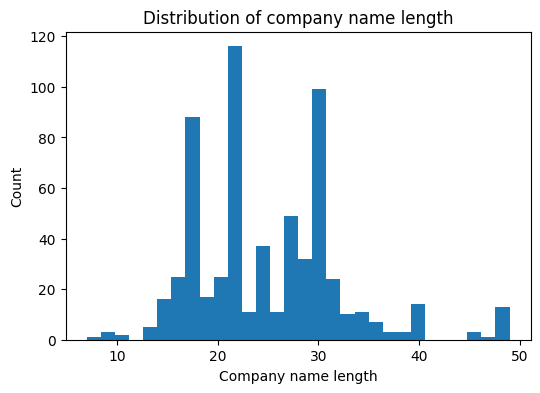

In [52]:
plt.figure(figsize=(6, 4))
plt.hist(df_clean["company_len"], bins=30)
plt.xlabel("Company name length")
plt.ylabel("Count")
plt.title("Distribution of company name length")
plt.show()

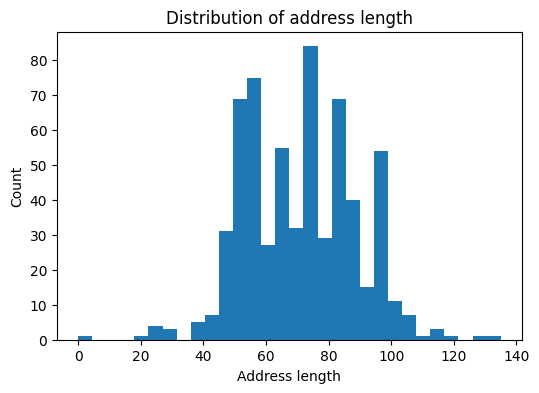

In [53]:
plt.figure(figsize=(6, 4))
plt.hist(df_clean["address_len"], bins=30)
plt.xlabel("Address length")
plt.ylabel("Count")
plt.title("Distribution of address length")
plt.show()

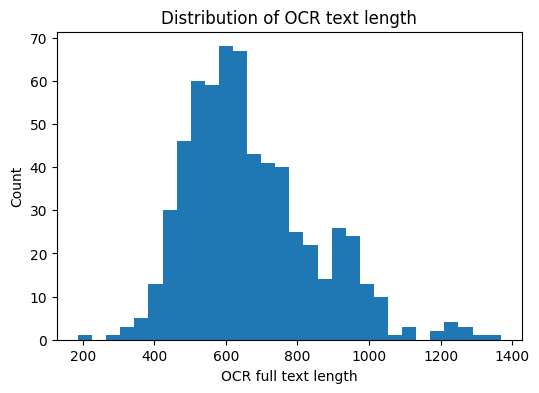

In [54]:
plt.figure(figsize=(6, 4))
plt.hist(df_clean["ocr_text_len"], bins=30)
plt.xlabel("OCR full text length")
plt.ylabel("Count")
plt.title("Distribution of OCR text length")
plt.show()

Label-In-OCR Checks

In [55]:
for col in ["company", "date", "address", "total"]:
    df_clean[f"{col}_in_ocr_exact"] = df_clean.apply(
        lambda row: str(row[col]) in row["ocr_full_text"] if pd.notna(row["ocr_full_text"]) else False,
        axis=1
    )

for col in ["company", "date", "address", "total"]:
    print(col, df_clean[f"{col}_in_ocr_exact"].mean())

company 0.9712460063897763
date 0.9936102236421726
address 0.7747603833865815
total 0.9984025559105432


In [57]:
df_clean.loc[~df_clean["company_in_ocr_exact"], ["receipt_id", "company", "ocr_full_text"]].head(5)

,receipt_id,company,ocr_full_text
0,X00016469612,BOOK TA .K (TAMAN DAYA) SDN BHD,TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 7...
2,X00016469620,MR D.I.Y. (JOHOR) SDN BHD,TAN WOON YANN MR D.T.Y. (JOHOR) SDN BHD (CO.RE...
27,X51005361907,TED HENG STATIONERY & BOOKS,TEO HENG STATIONERY & BOOKS (001451637-M) NO. ...
44,X51005441398,OWNER BY CASTLE BLUE S/B,BREWERY TAP DWNER BY CASTLE BLUE S/B (1035693-...
55,X51005442361,TIMELESS KITCHENETTE SDN BHD,MORGANFIELD'S R HORNG OF SDCKY BONES TIME LESS...


In [56]:
df_clean.loc[~df_clean["address_in_ocr_exact"], ["receipt_id", "address", "ocr_full_text"]].head(5)

,receipt_id,address,ocr_full_text
1,X00016469619,"27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...","TAN WOON YANN INDAH GIFT & HOME DECO 27,JALAN ..."
3,X00016469622,NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU,TAN WOON YANN YONGFATT ENTERPRISE (JM0517726) ...
5,X00016469669,"NO.2&4, JALAN HARMONI 3/2, TAMAN DESA HARMONI....","TAN CHAY YEE ABC HO TRADING NO.2&4,JALAN HARMO..."
6,X00016469672,"NO.53 JALAN PUTRA 1, TAMAN SRI PUTRA, 81200 JO...",TAN CHAY YEE SOON HUAT MACHINERY ENTERPRISE (J...
13,X51005268400,NO.2-1-1 JALAN SEITA PRIMA Q U 13/Q SEITA ALAM...,RESTORAN HASSANBISTRO NO.2-1-1 JALAN SETIA PRI...


Normalize for Less Harsh Matching

In [58]:
def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

In [59]:
df_clean["ocr_text_norm"] = df_clean["ocr_full_text"].apply(normalize_text)

for col in ["company", "date", "address", "total"]:
    df_clean[f"{col}_norm"] = df_clean[col].apply(normalize_text)
    df_clean[f"{col}_in_ocr_norm"] = df_clean.apply(
        lambda row: row[f"{col}_norm"] in row["ocr_text_norm"],
        axis=1
    )

for col in ["company", "date", "address", "total"]:
    print(col, "exact:", df_clean[f"{col}_in_ocr_exact"].mean(),
          "| normalized:", df_clean[f"{col}_in_ocr_norm"].mean())

company exact: 0.9712460063897763 | normalized: 0.9760383386581469
date exact: 0.9936102236421726 | normalized: 0.9952076677316294
address exact: 0.7747603833865815 | normalized: 0.9376996805111821
total exact: 0.9984025559105432 | normalized: 0.9984025559105432


Image-Level Structure Features

In [60]:
widths = []
heights = []

for path in df_clean["image_path"]:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

df_clean["img_width"] = widths
df_clean["img_height"] = heights
df_clean["aspect_ratio"] = df_clean["img_height"] / df_clean["img_width"]

df_clean[["img_width", "img_height", "aspect_ratio"]].describe()

,img_width,img_height,aspect_ratio
count,626.000000,626.000000,626.000000
mean,1325.750799,2355.865815,2.053973
std,1413.780721,1841.281085,0.486787
min,436.000000,605.000000,1.029491
25%,623.000000,1395.500000,1.721644
50%,812.000000,1682.500000,1.994480
75%,935.000000,2141.000000,2.361156
max,4961.000000,7016.000000,3.795091


Crude-Text Density Proxy

In [61]:
df_clean["ocr_lines_per_height"] = df_clean["num_ocr_lines"] / df_clean["img_height"]
df_clean["ocr_chars_per_height"] = df_clean["ocr_text_len"] / df_clean["img_height"]

df_clean[["ocr_lines_per_height", "ocr_chars_per_height"]].describe()

,ocr_lines_per_height,ocr_chars_per_height
count,626.000000,626.000000
mean,0.030392,0.380866
std,0.015000,0.176723
min,0.003706,0.056300
25%,0.021356,0.288182
50%,0.029582,0.357143
75%,0.035256,0.468743
max,0.079487,0.826122


XVI. Simple Date Parser

In [67]:
from datetime import datetime

def parse_date_string(x):
    if pd.isna(x):
        return pd.NaT

    x = str(x).strip()
    if x == "":
        return pd.NaT

    # remove wrapping parentheses like (06/12/2016)
    x = x.strip("()")
    x_upper = x.upper()

    date_formats = [
        "%d/%m/%Y",   # 25/12/2018
        "%d/%m/%y",   # 27/07/17
        "%d-%m-%y",   # 12-01-19
        "%d-%m-%Y",   # 23-01-2019
        "%d %b %Y",   # 05 MAR 2018
        "%d %b %y",   # 30 DEC 17
        "%d-%b-%Y",   # 24-MAR-2018
        "%d-%b-%y",   # 24-MAR-18
        "%Y-%m-%d",   # 2018-03-23
        "%Y%m%d",     # 20180304

        "%m/%d/%Y",   # 12/28/2017
        "%Y/%m/%d",   # 2018/02/22
        "%d.%m.%y",   # 11.02.18
        "%d/%b/%Y",   # 02/JAN/2017
        "%d/%b/%y",   # 02/JAN/17
        "%b %d, %Y",  # OCT 3, 2016
        "%d%m%Y",     # 25032018
    ]

    for fmt in date_formats:
        try:
            return datetime.strptime(x_upper, fmt)
        except ValueError:
            pass

    return pd.NaT

In [68]:
df_clean["date_parsed"] = df_clean["date"].apply(parse_date_string)
df_clean["date_std"] = df_clean["date_parsed"].dt.strftime("%Y-%m-%d")

print("Parsed successfully:", df_clean["date_parsed"].notna().sum())
print("Failed to parse:", df_clean["date_parsed"].isna().sum())

Parsed successfully: 626
Failed to parse: 0


In [69]:
df_clean.loc[df_clean["date_parsed"].isna(), ["receipt_id", "date"]].head(20)

,receipt_id,date


In [70]:
df_clean[["receipt_id", "date", "date_std"]].sample(15, random_state=42)

,receipt_id,date,date_std
508,X51007103688,27-04-18,2018-04-27
561,X51007339130,20/10/2017,2017-10-20
262,X51005806703,06/02/2018,2018-02-06
259,X51005806685,17/01/2018,2018-01-17
554,X51007339115,31/10/2017,2017-10-31
583,X51007339166,04/12/2017,2017-12-04
189,X51005719883,17-02-18,2018-02-17
82,X51005568827,29-10-2017,2017-10-29
618,X51007846325,02/06/18,2018-06-02
171,X51005711453,10/03/2018,2018-03-10


In [66]:
df_clean["year"] = df_clean["date_parsed"].dt.year
df_clean["month"] = df_clean["date_parsed"].dt.month

print(df_clean["year"].value_counts(dropna=False).sort_index())
print(df_clean["month"].value_counts(dropna=False).sort_index())

year
2016.0     30
2017.0    185
2018.0    394
2019.0      4
NaN        13
Name: count, dtype: int64
month
1.0      55
2.0      51
3.0     120
4.0      86
5.0      81
6.0      74
7.0      23
8.0      16
9.0      28
10.0     31
11.0     15
12.0     33
NaN      13
Name: count, dtype: int64


XVII. Noisy Receipts

In [72]:
df_clean.groupby("address_in_ocr_norm")[["address_len", "ocr_text_len", "num_ocr_lines", "img_height"]].mean()

,address_len,ocr_text_len,num_ocr_lines,img_height
address_in_ocr_norm,,,,
False,78.743590,595.102564,47.589744,1901.410256
True,70.189097,675.642249,54.122658,2386.059625


In [73]:
df_clean.groupby("company_in_ocr_norm")[["company_len", "ocr_text_len", "num_ocr_lines", "img_height"]].mean()

,company_len,ocr_text_len,num_ocr_lines,img_height
company_in_ocr_norm,,,,
False,26.266667,671.933333,56.866667,2217.533333
True,24.818331,670.592471,53.638298,2359.261866


Address Match Rate by Address Length

In [74]:
df_clean["address_len_bin"] = pd.qcut(df_clean["address_len"], q=4, duplicates="drop")

df_clean.groupby("address_len_bin")["address_in_ocr_norm"].mean()

address_len_bin
(-0.001, 56.0]    0.973404
(56.0, 72.0]      0.937984
(72.0, 85.0]      0.948571
(85.0, 135.0]     0.873134
Name: address_in_ocr_norm, dtype: float64

Company Match Rate by Company Length

In [75]:
df_clean["company_len_bin"] = pd.qcut(df_clean["company_len"], q=4, duplicates="drop")

df_clean.groupby("company_len_bin")["company_in_ocr_norm"].mean()

company_len_bin
(6.999, 19.25]    0.993631
(19.25, 24.0]     0.976331
(24.0, 30.0]      0.966825
(30.0, 49.0]      0.966292
Name: company_in_ocr_norm, dtype: float64

"Hard-Receipt" Flag/Score

In [76]:
df_clean["hard_receipt"] = (
    (~df_clean["company_in_ocr_norm"]) |
    (~df_clean["address_in_ocr_norm"]) |
    (~df_clean["date_in_ocr_norm"]) |
    (~df_clean["total_in_ocr_norm"])
)

df_clean["hard_receipt"].value_counts()
df_clean["hard_receipt"].mean()

0.0878594249201278

In [77]:
df_clean.groupby("hard_receipt")[[
    "company_len",
    "address_len",
    "ocr_text_len",
    "num_ocr_lines",
    "img_height",
    "total_num"
]].mean()

,company_len,address_len,ocr_text_len,num_ocr_lines,img_height,total_num
hard_receipt,,,,,,
False,24.907180,70.063047,676.297723,54.106830,2380.126095,56.337123
True,24.290909,77.563636,611.727273,49.654545,2104.000000,204.494909


XVIII. Top Merchants

In [78]:
top_merchants = df_clean["company"].value_counts().head(20)
top_merchants

company
GARDENIA BAKERIES (KL) SDN BHD                       45
UNIHAKKA INTERNATIONAL SDN BHD                       42
SANYU STATIONERY SHOP                                36
99 SPEED MART S/B                                    31
MR. D.I.Y. (M) SDN BHD                               29
RESTORAN WAN SHENG                                   26
SYARIKAT PERNIAGAAN GIN KEE                          22
AEON CO. (M) BHD                                     15
AIK HUAT HARDWARE ENTERPRISE (SETIA ALAM) SDN BHD    12
POPULAR BOOK CO. (M) SDN BHD                         12
MR. D.I.Y. (KUCHAI) SDN BHD                          12
KEDAI PAPAN YEW CHUAN                                12
ONE ONE THREE SEAFOOD RESTAURANT SDN BHD             12
GERBANG ALAF RESTAURANTS SDN BHD                      9
GUARDIAN HEALTH AND BEAUTY SDN BHD                    6
DOMINO'S PIZZA                                        5
TEO HENG STATIONERY & BOOKS                           4
LIAN HING STATIONERY SDN BHD            

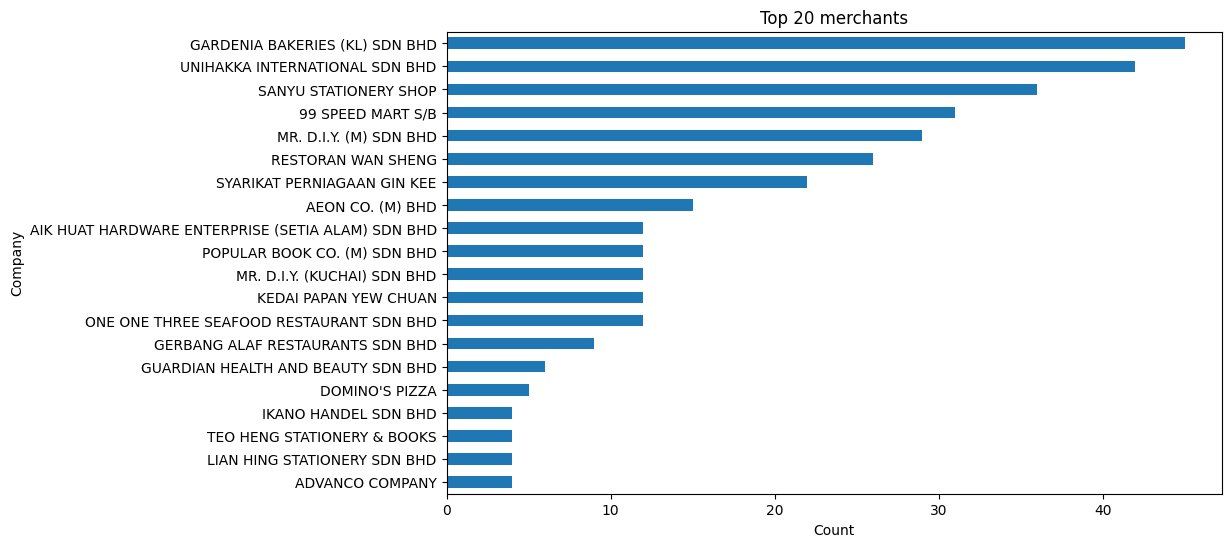

In [80]:
plt.figure(figsize=(10, 6))
top_merchants.sort_values().plot(kind="barh")
plt.xlabel("Count")
plt.ylabel("Company")
plt.title("Top 20 merchants")
plt.show()

In [81]:
merchant_counts = df_clean["company"].value_counts()

print("Unique merchants:", merchant_counts.shape[0])
print("Top 10 merchants share:", merchant_counts.head(10).sum() / len(df_clean))
print("Top 20 merchants share:", merchant_counts.head(20).sum() / len(df_clean))

Unique merchants: 236
Top 10 merchants share: 0.43130990415335463
Top 20 merchants share: 0.5463258785942492


XIX: OCR Line Count vs. OCR Text Length

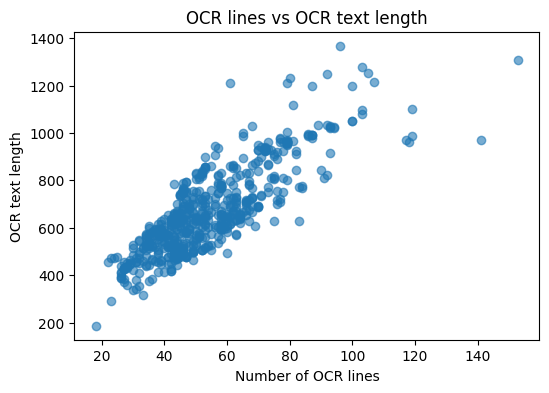

In [82]:
plt.figure(figsize=(6, 4))
plt.scatter(df_clean["num_ocr_lines"], df_clean["ocr_text_len"], alpha=0.6)
plt.xlabel("Number of OCR lines")
plt.ylabel("OCR text length")
plt.title("OCR lines vs OCR text length")
plt.show()

In [83]:
df_clean[["num_ocr_lines", "ocr_text_len", "img_height", "img_width"]].corr()

,num_ocr_lines,ocr_text_len,img_height,img_width
num_ocr_lines,1.000000,0.824708,0.087096,0.022927
ocr_text_len,0.824708,1.000000,0.096653,0.021463
img_height,0.087096,0.096653,1.000000,0.983554
img_width,0.022927,0.021463,0.983554,1.000000


XX: Hardest Receipts on Company/Address Matching

In [84]:
df_clean["num_field_failures"] = (
    (~df_clean["company_in_ocr_norm"]).astype(int) +
    (~df_clean["address_in_ocr_norm"]).astype(int) +
    (~df_clean["date_in_ocr_norm"]).astype(int) +
    (~df_clean["total_in_ocr_norm"]).astype(int)
)

df_clean["num_field_failures"].value_counts().sort_index()

num_field_failures
0    571
1     52
2      3
Name: count, dtype: int64

In [85]:
df_clean.loc[
    df_clean["num_field_failures"] >= 2,
    [
        "receipt_id", "company", "date", "address", "total",
        "num_field_failures", "ocr_full_text"
    ]
].head(10)

,receipt_id,company,date,address,total,num_field_failures,ocr_full_text
44,X51005441398,OWNER BY CASTLE BLUE S/B,30/03/2018,"AVTIVO PLAZA,LOT B-F-11, BLOCK B NO1.JALAN PJU...",189.75,2,BREWERY TAP DWNER BY CASTLE BLUE S/B (1035693-...
55,X51005442361,TIMELESS KITCHENETTE SDN BHD,2018-03-23,"LOT 50, FLOOR T2,SKY AVENUE GENTING HIGHLANDS ...",593.10,2,MORGANFIELD'S R HORNG OF SDCKY BONES TIME LESS...
179,X51005715451,POPULAR BOOK CO. (M) SDN BHD,06/02/18,"NO 8, JALAN 7/118B, DESA TAN RAZAH 56000 KUALA...",14.65,2,3-1708032 POPULAR BOOL CO. (M) SDN BHD (CO. NO...


In [86]:
df_clean.loc[
    (~df_clean["address_in_ocr_norm"]) | (~df_clean["company_in_ocr_norm"]),
    [
        "receipt_id", "company", "address",
        "company_in_ocr_norm", "address_in_ocr_norm",
        "ocr_full_text"
    ]
].head(10)

,receipt_id,company,address,company_in_ocr_norm,address_in_ocr_norm,ocr_full_text
0,X00016469612,BOOK TA .K (TAMAN DAYA) SDN BHD,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",False,True,TAN WOON YANN BOOK TA .K(TAMAN DAYA) SDN BND 7...
2,X00016469620,MR D.I.Y. (JOHOR) SDN BHD,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",False,True,TAN WOON YANN MR D.T.Y. (JOHOR) SDN BHD (CO.RE...
6,X00016469672,SOON HUAT MACHINERY ENTERPRISE,"NO.53 JALAN PUTRA 1, TAMAN SRI PUTRA, 81200 JO...",True,False,TAN CHAY YEE SOON HUAT MACHINERY ENTERPRISE (J...
13,X51005268400,RESTORAN HASSANBISTRO,NO.2-1-1 JALAN SEITA PRIMA Q U 13/Q SEITA ALAM...,True,False,RESTORAN HASSANBISTRO NO.2-1-1 JALAN SETIA PRI...
24,X51005361898,TEO HENG STATIONERY & BOOKS,"NO.53, JALAN BESAR, 45600 BATANG BEJUNTAL SELA...",True,False,TEO HENG STATIONERY & BOOKS (001451637-M) NO. ...
27,X51005361907,TED HENG STATIONERY & BOOKS,"NO. 53, JALAN BESAR, 45600 BATANG BERJUNTAI SE...",False,True,TEO HENG STATIONERY & BOOKS (001451637-M) NO. ...
36,X51005433494,AEON CO. (M) BHD,"3RD FLR, AEON TAMAN MALURI SD JLN JEJAKA, TAMA...",True,False,"AEON CO. (M) BHD (126926-H) 3RD FLR, AEON TAMA..."
44,X51005441398,OWNER BY CASTLE BLUE S/B,"AVTIVO PLAZA,LOT B-F-11, BLOCK B NO1.JALAN PJU...",False,False,BREWERY TAP DWNER BY CASTLE BLUE S/B (1035693-...
49,X51005442327,UNIHAKKA INTERNATIONAL SDN BHD,"12, JALAN TAMPOI 7/4,KAWASAN PARINDUSTRIAN TAM...",True,False,UNIHAKKA INTERNATIONAL SDN BHD 18 MAR 2018 18:...
50,X51005442333,UNIHAKKA INTERNATIONAL SDN BHD,"12, JALAN TAMPOI 7/4,KAWASAN PARINDUSTRIAN TAM...",True,False,UNIHAKKA INTERNATIONAL SDN BHD 27 MAR 2018 18:...


XXI. Outlier Review

In [87]:
df_clean.nlargest(10, "num_ocr_lines")[["receipt_id", "company", "num_ocr_lines", "ocr_text_len", "img_height", "total_num"]]

,receipt_id,company,num_ocr_lines,ocr_text_len,img_height,total_num
126,X51005663297,BEYOND BROTHERS HARDWARE,153,1308,3556,599.45
624,X51007846368,GRANDMA HOMES RESTAURANT,141,969,7016,473.30
14,X51005268472,ASIA MART,119,1100,2044,32.70
256,X51005806679,LEE WAH FLORIST SDN BHD,119,988,2559,374.20
361,X51006414713,YHM AEON TEBRAU CITY,118,961,7016,81.80
131,X51005663324,SYARIKAT PERNIAGAAN GIN KEE,117,971,2789,465.34
39,X51005433533,PERNIAGAAN ZHENG HUI,107,1214,1527,332.30
615,X51007846305,AEON CO. (M) BHD,105,1253,7016,127.35
158,X51005705760,TRI SHAAS SDN BHD,103,1279,2897,21.40
303,X51006335552,YONG SOON FATT S/B,103,1098,2452,758.70


In [88]:
df_clean.nlargest(10, "ocr_text_len")[["receipt_id", "company", "num_ocr_lines", "ocr_text_len", "img_height", "total_num"]]

,receipt_id,company,num_ocr_lines,ocr_text_len,img_height,total_num
441,X51006619545,COSWAY (M) SDN BHD,96,1368,3123,111.90
126,X51005663297,BEYOND BROTHERS HARDWARE,153,1308,3556,599.45
158,X51005705760,TRI SHAAS SDN BHD,103,1279,2897,21.40
615,X51007846305,AEON CO. (M) BHD,105,1253,7016,127.35
367,X51006414733,AEON CO. (M) BHD,92,1250,6981,122.80
487,X51006913019,AEON CO. (M) BHD,80,1232,7016,476.80
39,X51005433533,PERNIAGAAN ZHENG HUI,107,1214,1527,332.30
284,X51006327976,PREMIO STATIONERY SDN BHD,61,1211,1892,25.45
457,X51006619785,ECOSWAY.COM SDN BHD,79,1211,2900,78.30
103,X51005587267,TRI SHAAS SDN BHD,87,1197,2537,85.10


In [89]:
df_clean.nlargest(10, "img_height")[["receipt_id", "company", "img_width", "img_height", "num_ocr_lines", "ocr_text_len"]]

,receipt_id,company,img_width,img_height,num_ocr_lines,ocr_text_len
338,X51006414394,RESTORAN SIAM VILLAGE,4961,7016,76,754
339,X51006414429,UNIHAKKA INTERNATIONAL SDN BHD,4961,7016,39,579
340,X51006414431,UNIHAKKA INTERNATIONAL SDN BHD,4961,7016,35,538
341,X51006414470,UNIHAKKA INTERNATIONAL SDN BHD,4961,7016,39,565
342,X51006414483,UNIHAKKA INTERNATIONAL SDN BHD,4961,7016,39,582
343,X51006414485,UNIHAKKA INTERNATIONAL SDN BHD,4961,7016,39,580
344,X51006414519,HASHA PETROKIOSK,4961,7016,62,630
345,X51006414533,BHPETROL PERMAS JAYA 2,4961,7016,26,395
346,X51006414599,LAVENDER CONFECTIONERY & BAKERY S/B,4961,7016,56,947
348,X51006414633,UNIHAKKA INTERNATIONAL SDN BHD,4961,7016,39,579


XXII. Merchant-Level Difficulty

In [90]:
merchant_stats = (
    df_clean.groupby("company")
    .agg(
        n=("receipt_id", "size"),
        address_match=("address_in_ocr_norm", "mean"),
        company_match=("company_in_ocr_norm", "mean"),
        avg_total=("total_num", "mean"),
        avg_lines=("num_ocr_lines", "mean")
    )
    .sort_values("n", ascending=False)
)

merchant_stats.head(20)

,n,address_match,company_match,avg_total,avg_lines
company,,,,,
GARDENIA BAKERIES (KL) SDN BHD,45,1.000000,1.000000,41.053778,80.244444
UNIHAKKA INTERNATIONAL SDN BHD,42,0.904762,1.000000,8.339024,40.166667
SANYU STATIONERY SHOP,36,1.000000,1.000000,13.672222,48.777778
99 SPEED MART S/B,31,0.838710,1.000000,53.461290,33.451613
MR. D.I.Y. (M) SDN BHD,29,0.965517,1.000000,28.522414,45.310345
RESTORAN WAN SHENG,26,1.000000,1.000000,8.665385,47.692308
SYARIKAT PERNIAGAAN GIN KEE,22,0.954545,1.000000,75.799545,64.727273
AEON CO. (M) BHD,15,0.933333,1.000000,80.980000,57.666667
KEDAI PAPAN YEW CHUAN,12,1.000000,1.000000,179.537500,78.000000


XXIII. Save Dataset

In [ ]:
df_clean.to_csv("../outputs/eda/sroie_cleaned_eda.csv", index=False)

XXIV. Compact Merchant Summary

In [ ]:
merchant_stats.to_csv("../outputs/eda/sroie_merchant_stats.csv")